# Tugas Besar Machine Learning
## Perbandingan Performa CPU vs GPU pada Algoritma KMeans Clustering
**Platform:** Google Colab (GPU: Tesla T4, CUDA 12)  
**Algoritma:** KMeans (sklearn untuk CPU, cuML untuk GPU)  
**Dataset:**  
- *Kecil* : Iris · Seeds · Wine (UCI)  
- *Sedang* : Wine Quality · Adult · Dry Bean  
- *Besar* : Covertype · Poker Hand · Sensorless Drive  
- *Sangat Besar* : HIGGS · SUSY · Airline Delay  
**Metode Evaluasi:** Runtime, Speedup Ratio, Silhouette Score, Student's Welch t-Test


## 0. Informasi Hardware & Software
Cek spesifikasi GPU yang digunakan.

In [10]:
!nvidia-smi

Sat Jun 27 09:19:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [11]:
import subprocess
result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total,driver_version',
                         '--format=csv,noheader'], capture_output=True, text=True)
print('GPU Info:', result.stdout.strip())


GPU Info: Tesla T4, 15360 MiB, 580.82.07


In [12]:
!pip install cudf-cu12 cuml-cu12 --extra-index-url=https://pypi.nvidia.com -q

## 1. Import Library
Semua import dikumpulkan di satu tempat untuk keterbacaan dan reproducibility.

In [13]:
# Standard Library
import time
import tracemalloc

# Data Handling
import pandas as pd
import numpy as np

# Machine Learning - CPU
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.datasets import load_iris, fetch_covtype

# Machine Learning - GPU
import cupy as cp
from cuml.cluster import KMeans as cuKMeans

# Statistics
from scipy.stats import ttest_ind

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
np.random.seed(42)

print('Semua library berhasil diimport.')
print(f'NumPy version      : {np.__version__}')
print(f'Pandas version     : {pd.__version__}')
import sklearn; print(f'Scikit-learn ver.  : {sklearn.__version__}')
import scipy;   print(f'SciPy version      : {scipy.__version__}')
import cuml;    print(f'cuML version       : {cuml.__version__}')


Semua library berhasil diimport.
NumPy version      : 2.0.2
Pandas version     : 2.2.2
Scikit-learn ver.  : 1.6.1
SciPy version      : 1.16.3
cuML version       : 26.02.000


## 2. Fungsi Eksperimen
Fungsi `run_cpu` dan `run_gpu` dibuat generik (menerima parameter `n_clusters`)
agar tidak perlu didefinisikan ulang untuk setiap dataset.

**Catatan penting:**
- `n_init=10` diset sama di CPU dan GPU agar perbandingan adil.
- `cp.cuda.Stream.null.synchronize()` dipanggil sebelum mencatat waktu akhir GPU
  karena operasi CUDA bersifat *asynchronous* — tanpa sinkronisasi, timer bisa berhenti
  sebelum GPU selesai benar.


In [14]:
N_RUNS = 10          # jumlah percobaan per eksperimen
ALPHA  = 0.05        # tingkat signifikansi uji hipotesis

def run_cpu(X, n_clusters=3, n_init=10, random_state=42):
    """Jalankan KMeans di CPU, kembalikan (runtime_detik, labels)."""
    model = KMeans(n_clusters=n_clusters, random_state=random_state,
                   n_init=n_init)
    start = time.perf_counter()
    model.fit(X)
    elapsed = time.perf_counter() - start
    return elapsed, model.labels_

def run_gpu(X_gpu, n_clusters=3, n_init=10, random_state=42):
    """Jalankan KMeans di GPU, kembalikan (runtime_detik, labels).
    Sinkronisasi CUDA dilakukan sebelum mencatat waktu akhir."""
    model = cuKMeans(n_clusters=n_clusters, random_state=random_state,
                     n_init=n_init)
    start = time.perf_counter()
    model.fit(X_gpu)
    cp.cuda.Stream.null.synchronize()   # tunggu GPU benar-benar selesai
    elapsed = time.perf_counter() - start
    return elapsed, model.labels_.get()  # pindahkan labels ke CPU

def gpu_warmup(X_gpu, n_clusters=3):
    """GPU warm-up: run sekali untuk inisialisasi JIT CUDA."""
    run_gpu(X_gpu, n_clusters=n_clusters)
    print('GPU warm-up selesai.')

def run_experiment(X_cpu, X_gpu, n_clusters, label=''):
    """
    Jalankan N_RUNS kali eksperimen CPU dan GPU.
    Kembalikan dict berisi semua metrik.
    """
    # -- Warm-up GPU sebelum eksperimen (penting!) --
    gpu_warmup(X_gpu, n_clusters=n_clusters)

    cpu_times, gpu_times = [], []
    for i in range(N_RUNS):
        t_cpu, _ = run_cpu(X_cpu, n_clusters=n_clusters)
        t_gpu, _ = run_gpu(X_gpu, n_clusters=n_clusters)
        cpu_times.append(t_cpu)
        gpu_times.append(t_gpu)

    # Silhouette Score menggunakan hasil run terakhir CPU
    _, labels_cpu = run_cpu(X_cpu, n_clusters=n_clusters)
    sil  = silhouette_score(X_cpu, labels_cpu, sample_size=min(5000, len(X_cpu)),
                            random_state=42)
    dbi  = davies_bouldin_score(X_cpu, labels_cpu)

    avg_cpu  = np.mean(cpu_times)
    avg_gpu  = np.mean(gpu_times)
    std_cpu  = np.std(cpu_times)
    std_gpu  = np.std(gpu_times)
    speedup  = avg_cpu / avg_gpu

    # Welch t-Test
    t_stat, p_val = ttest_ind(cpu_times, gpu_times, equal_var=False)

    return {
        'cpu_times' : cpu_times,
        'gpu_times' : gpu_times,
        'avg_cpu'   : avg_cpu,
        'avg_gpu'   : avg_gpu,
        'std_cpu'   : std_cpu,
        'std_gpu'   : std_gpu,
        'speedup'   : speedup,
        'silhouette': sil,
        'dbi'       : dbi,
        't_stat'    : t_stat,
        'p_value'   : p_val,
        'label'     : label,
    }


## 3. Hipotesis Penelitian

Sebelum eksperimen, kita tetapkan hipotesis secara formal:

- **H₀ (Hipotesis Nol):** Tidak ada perbedaan signifikan antara rata-rata runtime KMeans
  pada CPU dan GPU  
  → μ_CPU = μ_GPU
- **H₁ (Hipotesis Alternatif):** Terdapat perbedaan signifikan antara rata-rata runtime
  KMeans pada CPU dan GPU  
  → μ_CPU ≠ μ_GPU
- **Tingkat signifikansi (α):** 0.05

Uji yang digunakan: **Independent Welch t-Test** (`equal_var=False`) karena variansi
CPU dan GPU tidak diasumsikan sama.  
Keputusan: tolak H₀ jika **p-value < α**.


## 4. Dataset Kecil — Iris
**Sumber:** `sklearn.datasets.load_iris` (built-in, public domain)  
<https://archive.ics.uci.edu/dataset/53/iris>

**Ukuran:** 150 baris × 4 fitur  
**Kategori kelas:** 3 (setosa, versicolor, virginica) → `n_clusters = 3`


In [15]:
iris = load_iris()
X_iris_raw = pd.DataFrame(iris.data, columns=iris.feature_names)

print('Shape:', X_iris_raw.shape)
print('Missing values:', X_iris_raw.isnull().sum().sum())
print('Duplikat      :', X_iris_raw.duplicated().sum())
X_iris_raw.describe()


Shape: (150, 4)
Missing values: 0
Duplikat      : 1


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [16]:
scaler_iris = StandardScaler()
X_iris = scaler_iris.fit_transform(X_iris_raw)
X_iris_gpu = cp.asarray(X_iris)
print('Preprocessing selesai. Shape:', X_iris.shape)


Preprocessing selesai. Shape: (150, 4)


In [17]:
res_iris = run_experiment(X_iris, X_iris_gpu, n_clusters=3, label='Iris')
print(f"CPU Avg  : {res_iris['avg_cpu']:.6f} s  (±{res_iris['std_cpu']:.6f})")
print(f"GPU Avg  : {res_iris['avg_gpu']:.6f} s  (±{res_iris['std_gpu']:.6f})")
print(f"Speedup  : {res_iris['speedup']:.4f}x")
print(f"Silhouette Score : {res_iris['silhouette']:.4f}")
print(f"Davies-Bouldin   : {res_iris['dbi']:.4f}")
print(f"t-statistic      : {res_iris['t_stat']:.4f}")
print(f"p-value          : {res_iris['p_value']:.4e}")

if res_iris['p_value'] < ALPHA:
    print(f"Keputusan: Tolak H0 (p={res_iris['p_value']:.4e} < α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU SIGNIFIKAN.")
else:
    print(f"Keputusan: Gagal tolak H0 (p={res_iris['p_value']:.4e} >= α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU TIDAK signifikan.")


GPU warm-up selesai.
CPU Avg  : 0.017005 s  (±0.007750)
GPU Avg  : 0.037541 s  (±0.004419)
Speedup  : 0.4530x
Silhouette Score : 0.4599
Davies-Bouldin   : 0.8336
t-statistic      : -6.9058
p-value          : 6.4945e-06
Keputusan: Tolak H0 (p=6.4945e-06 < α=0.05) → perbedaan runtime CPU-GPU SIGNIFIKAN.


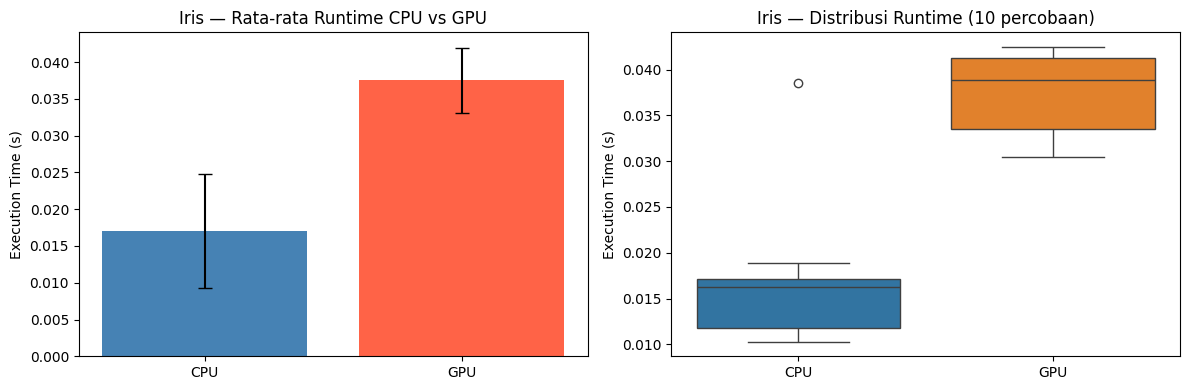

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart dengan error bar
axes[0].bar(['CPU', 'GPU'],
            [res_iris['avg_cpu'], res_iris['avg_gpu']],
            yerr=[res_iris['std_cpu'], res_iris['std_gpu']],
            color=['steelblue', 'tomato'], capsize=5)
axes[0].set_ylabel('Execution Time (s)')
axes[0].set_title('Iris — Rata-rata Runtime CPU vs GPU')

# Box plot
plot_df = pd.DataFrame({'CPU': res_iris['cpu_times'], 'GPU': res_iris['gpu_times']})
sns.boxplot(data=plot_df, ax=axes[1])
axes[1].set_ylabel('Execution Time (s)')
axes[1].set_title('Iris — Distribusi Runtime (10 percobaan)')

plt.tight_layout()
plt.show()


## 4b. Dataset Kecil — Seeds
**Sumber:** UCI Machine Learning Repository  
<https://archive.ics.uci.edu/dataset/236/seeds>  
**Ukuran:** 210 baris × 7 fitur (geometri benih gandum)  
**n_clusters = 3** (3 varietas gandum: Kama, Rosa, Canadian)

In [19]:
seeds_url = (
    'https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt'
)
df_seeds = pd.read_csv(
    seeds_url, sep=r'\s+', header=None,
    names=['area','perimeter','compactness','length_kernel',
           'width_kernel','asymmetry','groove_length','label']
)
print('Shape          :', df_seeds.shape)
print('Missing values :', df_seeds.isnull().sum().sum())
print('Duplikat       :', df_seeds.duplicated().sum())
df_seeds.describe()

Shape          : (210, 8)
Missing values : 0
Duplikat       : 0


,area,perimeter,compactness,length_kernel,width_kernel,asymmetry,groove_length,label
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


In [20]:
X_seeds_raw = df_seeds.drop('label', axis=1)
scaler_seeds = StandardScaler()
X_seeds = scaler_seeds.fit_transform(X_seeds_raw)
X_seeds_gpu = cp.asarray(X_seeds)
print('Preprocessing selesai. Shape:', X_seeds.shape)

Preprocessing selesai. Shape: (210, 7)


In [21]:
res_seeds = run_experiment(X_seeds, X_seeds_gpu, n_clusters=3, label='Seeds')
print(f"CPU Avg  : {res_seeds['avg_cpu']:.6f} s  (±{res_seeds['std_cpu']:.6f})")
print(f"GPU Avg  : {res_seeds['avg_gpu']:.6f} s  (±{res_seeds['std_gpu']:.6f})")
print(f"Speedup  : {res_seeds['speedup']:.4f}x")
print(f"Silhouette Score : {res_seeds['silhouette']:.4f}")
print(f"Davies-Bouldin   : {res_seeds['dbi']:.4f}")
print(f"t-statistic      : {res_seeds['t_stat']:.4f}")
print(f"p-value          : {res_seeds['p_value']:.4e}")

if res_seeds['p_value'] < ALPHA:
    print(f"Keputusan: Tolak H0 (p={res_seeds['p_value']:.4e} < α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU SIGNIFIKAN.")
else:
    print(f"Keputusan: Gagal tolak H0 (p={res_seeds['p_value']:.4e} >= α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU TIDAK signifikan.")

GPU warm-up selesai.
CPU Avg  : 0.017579 s  (±0.005035)
GPU Avg  : 0.050098 s  (±0.029633)
Speedup  : 0.3509x
Silhouette Score : 0.4007
Davies-Bouldin   : 0.9279
t-statistic      : -3.2457
p-value          : 9.3579e-03
Keputusan: Tolak H0 (p=9.3579e-03 < α=0.05) → perbedaan runtime CPU-GPU SIGNIFIKAN.


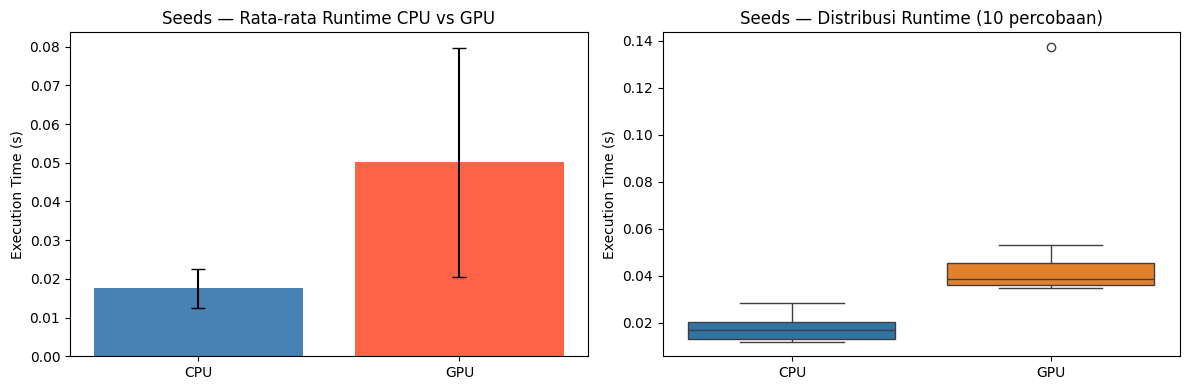

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['CPU', 'GPU'],
            [res_seeds['avg_cpu'], res_seeds['avg_gpu']],
            yerr=[res_seeds['std_cpu'], res_seeds['std_gpu']],
            color=['steelblue', 'tomato'], capsize=5)
axes[0].set_ylabel('Execution Time (s)')
axes[0].set_title('Seeds — Rata-rata Runtime CPU vs GPU')

plot_df = pd.DataFrame({'CPU': res_seeds['cpu_times'], 'GPU': res_seeds['gpu_times']})
sns.boxplot(data=plot_df, ax=axes[1])
axes[1].set_ylabel('Execution Time (s)')
axes[1].set_title('Seeds — Distribusi Runtime (10 percobaan)')
plt.tight_layout(); plt.show()

## 4c. Dataset Kecil — Wine (UCI)
**Sumber:** UCI Machine Learning Repository  
<https://archive.ics.uci.edu/dataset/109/wine>  
**Ukuran:** 178 baris × 13 fitur (analisis kimia wine Italia)  
**n_clusters = 3** (3 kultivar anggur)

In [23]:
from sklearn.datasets import load_wine
wine_uci = load_wine()
X_wine_uci_raw = pd.DataFrame(wine_uci.data, columns=wine_uci.feature_names)
print('Shape          :', X_wine_uci_raw.shape)
print('Missing values :', X_wine_uci_raw.isnull().sum().sum())
print('Duplikat       :', X_wine_uci_raw.duplicated().sum())
X_wine_uci_raw.describe()

Shape          : (178, 13)
Missing values : 0
Duplikat       : 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [24]:
scaler_wine_uci = StandardScaler()
X_wine_uci = scaler_wine_uci.fit_transform(X_wine_uci_raw)
X_wine_uci_gpu = cp.asarray(X_wine_uci)
print('Preprocessing selesai. Shape:', X_wine_uci.shape)

Preprocessing selesai. Shape: (178, 13)


In [25]:
res_wine_uci = run_experiment(X_wine_uci, X_wine_uci_gpu, n_clusters=3, label='Wine UCI')
print(f"CPU Avg  : {res_wine_uci['avg_cpu']:.6f} s  (±{res_wine_uci['std_cpu']:.6f})")
print(f"GPU Avg  : {res_wine_uci['avg_gpu']:.6f} s  (±{res_wine_uci['std_gpu']:.6f})")
print(f"Speedup  : {res_wine_uci['speedup']:.4f}x")
print(f"Silhouette Score : {res_wine_uci['silhouette']:.4f}")
print(f"Davies-Bouldin   : {res_wine_uci['dbi']:.4f}")
print(f"t-statistic      : {res_wine_uci['t_stat']:.4f}")
print(f"p-value          : {res_wine_uci['p_value']:.4e}")

if res_wine_uci['p_value'] < ALPHA:
    print(f"Keputusan: Tolak H0 (p={res_wine_uci['p_value']:.4e} < α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU SIGNIFIKAN.")
else:
    print(f"Keputusan: Gagal tolak H0 (p={res_wine_uci['p_value']:.4e} >= α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU TIDAK signifikan.")

GPU warm-up selesai.
CPU Avg  : 0.026262 s  (±0.003358)
GPU Avg  : 0.091146 s  (±0.032478)
Speedup  : 0.2881x
Silhouette Score : 0.2849
Davies-Bouldin   : 1.3892
t-statistic      : -5.9616
p-value          : 1.9512e-04
Keputusan: Tolak H0 (p=1.9512e-04 < α=0.05) → perbedaan runtime CPU-GPU SIGNIFIKAN.


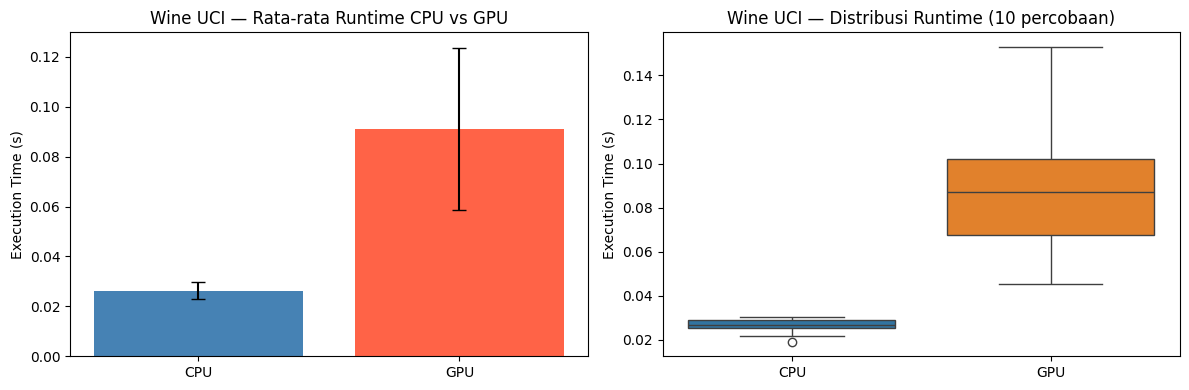

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['CPU', 'GPU'],
            [res_wine_uci['avg_cpu'], res_wine_uci['avg_gpu']],
            yerr=[res_wine_uci['std_cpu'], res_wine_uci['std_gpu']],
            color=['steelblue', 'tomato'], capsize=5)
axes[0].set_ylabel('Execution Time (s)')
axes[0].set_title('Wine UCI — Rata-rata Runtime CPU vs GPU')

plot_df = pd.DataFrame({'CPU': res_wine_uci['cpu_times'], 'GPU': res_wine_uci['gpu_times']})
sns.boxplot(data=plot_df, ax=axes[1])
axes[1].set_ylabel('Execution Time (s)')
axes[1].set_title('Wine UCI — Distribusi Runtime (10 percobaan)')
plt.tight_layout(); plt.show()

## 5. Dataset Sedang — Wine Quality
**Sumber:** UCI Machine Learning Repository  
<https://archive.ics.uci.edu/dataset/186/wine+quality/>  
**Ukuran:** ~6.497 baris × 11 fitur (red + white wine digabung)  
**n_clusters = 3** (kualitas wine dikategorikan rendah/sedang/tinggi)


In [27]:
red_url   = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
white_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'

red   = pd.read_csv(red_url,   sep=';')
white = pd.read_csv(white_url, sep=';')
df_wine = pd.concat([red, white], ignore_index=True)

print('Shape          :', df_wine.shape)
print('Missing values :', df_wine.isnull().sum().sum())
print('Duplikat       :', df_wine.duplicated().sum())
df_wine.info()


Shape          : (6497, 12)
Missing values : 0
Duplikat       : 1179
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB


In [28]:
# Hapus duplikat jika ada
df_wine = df_wine.drop_duplicates()
print('Shape setelah drop_duplicates:', df_wine.shape)

X_wine_raw = df_wine.drop('quality', axis=1)
scaler_wine = StandardScaler()
X_wine = scaler_wine.fit_transform(X_wine_raw)
X_wine_gpu = cp.asarray(X_wine)
print('Preprocessing selesai. Shape:', X_wine.shape)


Shape setelah drop_duplicates: (5318, 12)
Preprocessing selesai. Shape: (5318, 11)


In [29]:
res_wine = run_experiment(X_wine, X_wine_gpu, n_clusters=3, label='Wine Quality')
print(f"CPU Avg  : {res_wine['avg_cpu']:.6f} s  (±{res_wine['std_cpu']:.6f})")
print(f"GPU Avg  : {res_wine['avg_gpu']:.6f} s  (±{res_wine['std_gpu']:.6f})")
print(f"Speedup  : {res_wine['speedup']:.4f}x")
print(f"Silhouette Score : {res_wine['silhouette']:.4f}")
print(f"Davies-Bouldin   : {res_wine['dbi']:.4f}")
print(f"t-statistic      : {res_wine['t_stat']:.4f}")
print(f"p-value          : {res_wine['p_value']:.4e}")

if res_wine['p_value'] < ALPHA:
    print(f"Keputusan: Tolak H0 (p={res_wine['p_value']:.4e} < α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU SIGNIFIKAN.")
else:
    print(f"Keputusan: Gagal tolak H0 (p={res_wine['p_value']:.4e} >= α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU TIDAK signifikan.")


GPU warm-up selesai.
CPU Avg  : 0.187117 s  (±0.055428)
GPU Avg  : 0.344351 s  (±0.143834)
Speedup  : 0.5434x
Silhouette Score : 0.2296
Davies-Bouldin   : 1.5072
t-statistic      : -3.0601
p-value          : 1.0239e-02
Keputusan: Tolak H0 (p=1.0239e-02 < α=0.05) → perbedaan runtime CPU-GPU SIGNIFIKAN.


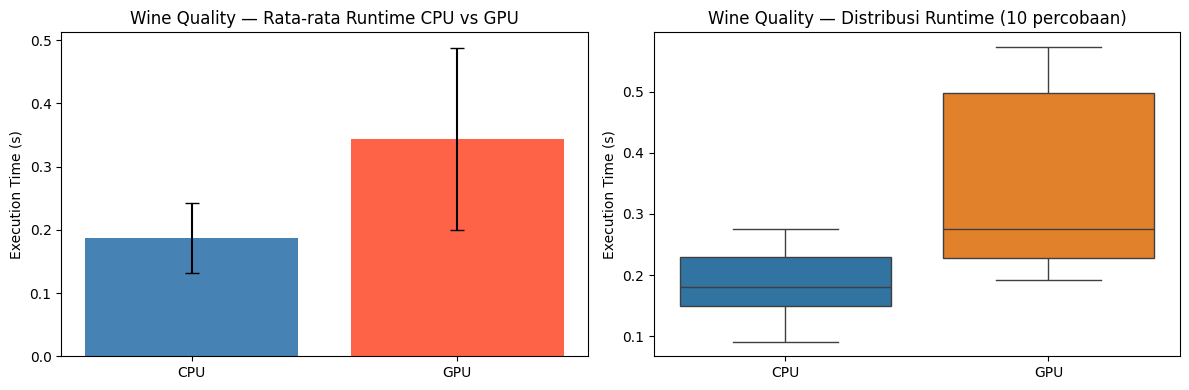

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['CPU', 'GPU'],
            [res_wine['avg_cpu'], res_wine['avg_gpu']],
            yerr=[res_wine['std_cpu'], res_wine['std_gpu']],
            color=['steelblue', 'tomato'], capsize=5)
axes[0].set_ylabel('Execution Time (s)')
axes[0].set_title('Wine Quality — Rata-rata Runtime CPU vs GPU')

plot_df = pd.DataFrame({'CPU': res_wine['cpu_times'], 'GPU': res_wine['gpu_times']})
sns.boxplot(data=plot_df, ax=axes[1])
axes[1].set_ylabel('Execution Time (s)')
axes[1].set_title('Wine Quality — Distribusi Runtime (10 percobaan)')
plt.tight_layout(); plt.show()


## 5b. Dataset Sedang — Adult (Census Income)
**Sumber:** UCI Machine Learning Repository  
<https://archive.ics.uci.edu/dataset/2/adult>  
**Ukuran:** ~48.842 baris × 6 fitur numerik (setelah seleksi fitur)  
**n_clusters = 3** (segmentasi demografi pendapatan)

In [31]:
adult_url = (
    'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
)
adult_cols = ['age','workclass','fnlwgt','education','education_num','marital_status',
              'occupation','relationship','race','sex','capital_gain','capital_loss',
              'hours_per_week','native_country','income']
df_adult = pd.read_csv(adult_url, header=None, names=adult_cols,
                       sep=', ', engine='python', na_values='?')
print('Shape          :', df_adult.shape)
print('Missing values :', df_adult.isnull().sum().sum())
print('Duplikat       :', df_adult.duplicated().sum())
df_adult.head()

Shape          : (32561, 15)
Missing values : 4262
Duplikat       : 24


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [32]:
# Pilih fitur numerik saja untuk clustering
adult_num_cols = ['age','fnlwgt','education_num','capital_gain','capital_loss','hours_per_week']
df_adult_clean = df_adult[adult_num_cols].dropna().drop_duplicates()
print('Shape setelah preprocessing:', df_adult_clean.shape)

scaler_adult = StandardScaler()
X_adult = scaler_adult.fit_transform(df_adult_clean)
X_adult_gpu = cp.asarray(X_adult)
print('Preprocessing selesai. Shape:', X_adult.shape)

Shape setelah preprocessing: (32334, 6)
Preprocessing selesai. Shape: (32334, 6)


In [33]:
res_adult = run_experiment(X_adult, X_adult_gpu, n_clusters=3, label='Adult')
print(f"CPU Avg  : {res_adult['avg_cpu']:.6f} s  (±{res_adult['std_cpu']:.6f})")
print(f"GPU Avg  : {res_adult['avg_gpu']:.6f} s  (±{res_adult['std_gpu']:.6f})")
print(f"Speedup  : {res_adult['speedup']:.4f}x")
print(f"Silhouette Score : {res_adult['silhouette']:.4f}")
print(f"Davies-Bouldin   : {res_adult['dbi']:.4f}")
print(f"t-statistic      : {res_adult['t_stat']:.4f}")
print(f"p-value          : {res_adult['p_value']:.4e}")

if res_adult['p_value'] < ALPHA:
    print(f"Keputusan: Tolak H0 (p={res_adult['p_value']:.4e} < α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU SIGNIFIKAN.")
else:
    print(f"Keputusan: Gagal tolak H0 (p={res_adult['p_value']:.4e} >= α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU TIDAK signifikan.")

GPU warm-up selesai.
CPU Avg  : 0.842092 s  (±0.248121)
GPU Avg  : 0.297435 s  (±0.113435)
Speedup  : 2.8312x
Silhouette Score : 0.1933
Davies-Bouldin   : 1.5659
t-statistic      : 5.9892
p-value          : 5.1491e-05
Keputusan: Tolak H0 (p=5.1491e-05 < α=0.05) → perbedaan runtime CPU-GPU SIGNIFIKAN.


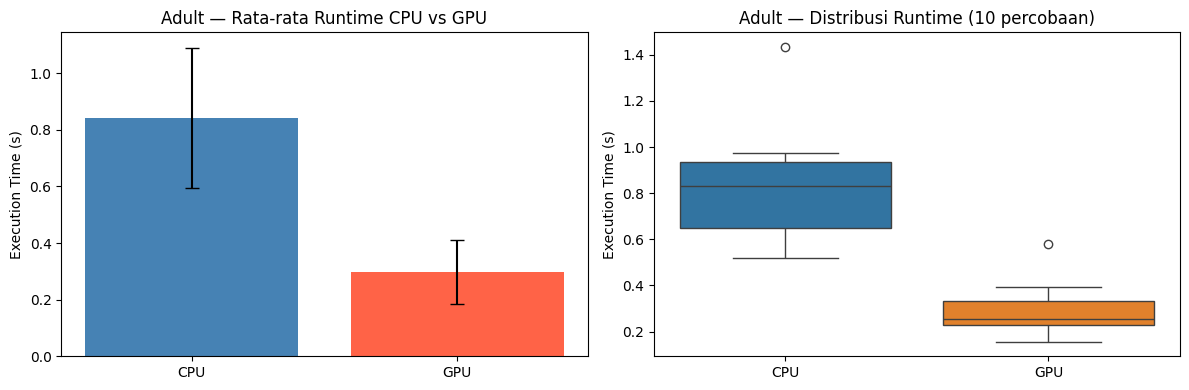

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['CPU', 'GPU'],
            [res_adult['avg_cpu'], res_adult['avg_gpu']],
            yerr=[res_adult['std_cpu'], res_adult['std_gpu']],
            color=['steelblue', 'tomato'], capsize=5)
axes[0].set_ylabel('Execution Time (s)')
axes[0].set_title('Adult — Rata-rata Runtime CPU vs GPU')

plot_df = pd.DataFrame({'CPU': res_adult['cpu_times'], 'GPU': res_adult['gpu_times']})
sns.boxplot(data=plot_df, ax=axes[1])
axes[1].set_ylabel('Execution Time (s)')
axes[1].set_title('Adult — Distribusi Runtime (10 percobaan)')
plt.tight_layout(); plt.show()

## 5c. Dataset Sedang — Dry Bean
**Sumber:** UCI Machine Learning Repository  
<https://archive.ics.uci.edu/dataset/602/dry+bean+dataset>  
**Ukuran:** 13.611 baris × 16 fitur (morfologi biji kacang)  
**n_clusters = 7** (7 varietas kacang: Seker, Barbunya, Bombay, Cali, Dermason, Horoz, Sira)

In [35]:
# Download via requests karena file Excel (.xlsx)
import requests, io
drybean_url = (
    'https://archive.ics.uci.edu/ml/machine-learning-databases/00602/DryBeanDataset.zip'
)
# Alternatif: gunakan versi CSV yang tersedia di Kaggle
# Untuk Colab/Jupyter, kita download langsung dari UCI
resp = requests.get(drybean_url, timeout=60)
import zipfile
with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
    # File di dalam zip: Dry_Bean_Dataset.xlsx
    with z.open('DryBeanDataset/Dry_Bean_Dataset.xlsx') as f:
        df_drybean = pd.read_excel(f)

print('Shape          :', df_drybean.shape)
print('Missing values :', df_drybean.isnull().sum().sum())
print('Duplikat       :', df_drybean.duplicated().sum())
df_drybean.head()

Shape          : (13611, 17)
Missing values : 0
Duplikat       : 68


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [36]:
X_drybean_raw = df_drybean.drop('Class', axis=1)
scaler_drybean = StandardScaler()
X_drybean = scaler_drybean.fit_transform(X_drybean_raw)
X_drybean_gpu = cp.asarray(X_drybean)
print('Preprocessing selesai. Shape:', X_drybean.shape)

Preprocessing selesai. Shape: (13611, 16)


In [37]:
res_drybean = run_experiment(X_drybean, X_drybean_gpu, n_clusters=7, label='Dry Bean')
print(f"CPU Avg  : {res_drybean['avg_cpu']:.6f} s  (±{res_drybean['std_cpu']:.6f})")
print(f"GPU Avg  : {res_drybean['avg_gpu']:.6f} s  (±{res_drybean['std_gpu']:.6f})")
print(f"Speedup  : {res_drybean['speedup']:.4f}x")
print(f"Silhouette Score : {res_drybean['silhouette']:.4f}")
print(f"Davies-Bouldin   : {res_drybean['dbi']:.4f}")
print(f"t-statistic      : {res_drybean['t_stat']:.4f}")
print(f"p-value          : {res_drybean['p_value']:.4e}")

if res_drybean['p_value'] < ALPHA:
    print(f"Keputusan: Tolak H0 (p={res_drybean['p_value']:.4e} < α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU SIGNIFIKAN.")
else:
    print(f"Keputusan: Gagal tolak H0 (p={res_drybean['p_value']:.4e} >= α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU TIDAK signifikan.")

GPU warm-up selesai.
CPU Avg  : 0.390959 s  (±0.016684)
GPU Avg  : 0.169241 s  (±0.010700)
Speedup  : 2.3101x
Silhouette Score : 0.3098
Davies-Bouldin   : 1.0993
t-statistic      : 33.5592
p-value          : 8.9958e-16
Keputusan: Tolak H0 (p=8.9958e-16 < α=0.05) → perbedaan runtime CPU-GPU SIGNIFIKAN.


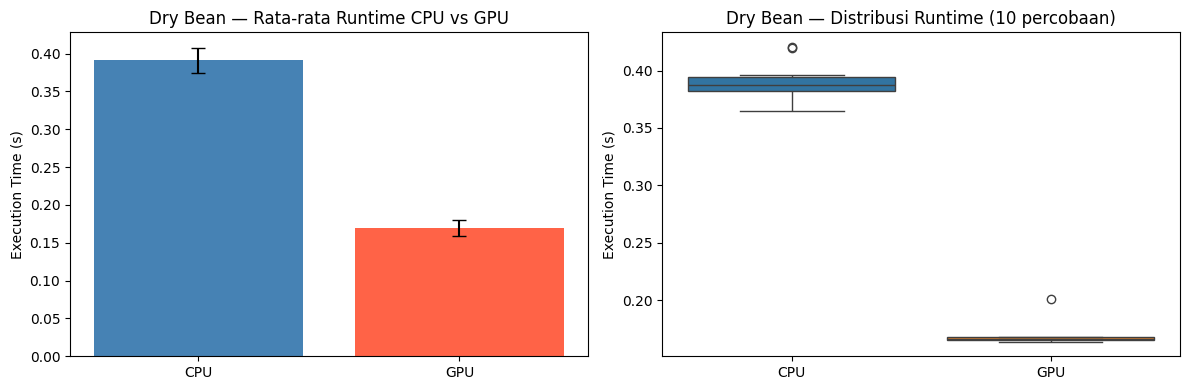

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['CPU', 'GPU'],
            [res_drybean['avg_cpu'], res_drybean['avg_gpu']],
            yerr=[res_drybean['std_cpu'], res_drybean['std_gpu']],
            color=['steelblue', 'tomato'], capsize=5)
axes[0].set_ylabel('Execution Time (s)')
axes[0].set_title('Dry Bean — Rata-rata Runtime CPU vs GPU')

plot_df = pd.DataFrame({'CPU': res_drybean['cpu_times'], 'GPU': res_drybean['gpu_times']})
sns.boxplot(data=plot_df, ax=axes[1])
axes[1].set_ylabel('Execution Time (s)')
axes[1].set_title('Dry Bean — Distribusi Runtime (10 percobaan)')
plt.tight_layout(); plt.show()

## 6. Dataset Besar — Covertype
**Sumber:** `sklearn.datasets.fetch_covtype` (UCI Covertype Dataset, public domain)  
<https://archive.ics.uci.edu/dataset/31/covertype>

**Ukuran:** 581.012 baris × 54 fitur  
**n_clusters = 7** (sesuai 7 kelas tipe hutan dalam dataset asli)


In [39]:
covtype = fetch_covtype()
df_cover = pd.DataFrame(covtype.data)

print('Shape          :', df_cover.shape)
print('Missing values :', df_cover.isnull().sum().sum())
print('Duplikat       :', df_cover.duplicated().sum())


Shape          : (581012, 54)
Missing values : 0
Duplikat       : 0


In [40]:
scaler_cover = StandardScaler()
X_cover = scaler_cover.fit_transform(df_cover.values)
X_cover_gpu = cp.asarray(X_cover)
print('Preprocessing selesai. Shape:', X_cover.shape)


Preprocessing selesai. Shape: (581012, 54)


In [41]:
res_cover = run_experiment(X_cover, X_cover_gpu, n_clusters=7, label='Covertype')
print(f"CPU Avg  : {res_cover['avg_cpu']:.4f} s  (±{res_cover['std_cpu']:.4f})")
print(f"GPU Avg  : {res_cover['avg_gpu']:.4f} s  (±{res_cover['std_gpu']:.4f})")
print(f"Speedup  : {res_cover['speedup']:.4f}x")
print(f"Silhouette Score : {res_cover['silhouette']:.4f}")
print(f"Davies-Bouldin   : {res_cover['dbi']:.4f}")
print(f"t-statistic      : {res_cover['t_stat']:.4f}")
print(f"p-value          : {res_cover['p_value']:.4e}")

if res_cover['p_value'] < ALPHA:
    print(f"Keputusan: Tolak H0 (p={res_cover['p_value']:.4e} < α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU SIGNIFIKAN.")
else:
    print(f"Keputusan: Gagal tolak H0 (p={res_cover['p_value']:.4e} >= α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU TIDAK signifikan.")


GPU warm-up selesai.
CPU Avg  : 26.2370 s  (±2.3796)
GPU Avg  : 5.5227 s  (±0.1704)
Speedup  : 4.7508x
Silhouette Score : 0.0890
Davies-Bouldin   : 1.9595
t-statistic      : 26.0485
p-value          : 7.4529e-10
Keputusan: Tolak H0 (p=7.4529e-10 < α=0.05) → perbedaan runtime CPU-GPU SIGNIFIKAN.


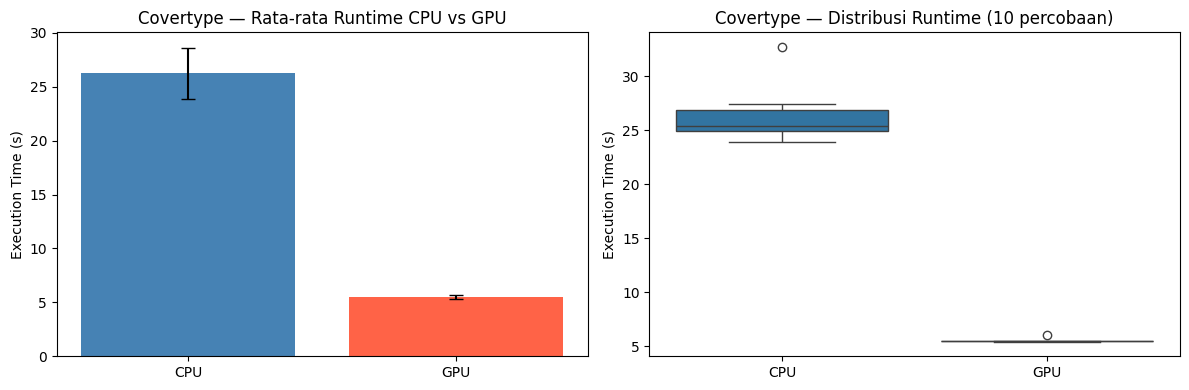

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['CPU', 'GPU'],
            [res_cover['avg_cpu'], res_cover['avg_gpu']],
            yerr=[res_cover['std_cpu'], res_cover['std_gpu']],
            color=['steelblue', 'tomato'], capsize=5)
axes[0].set_ylabel('Execution Time (s)')
axes[0].set_title('Covertype — Rata-rata Runtime CPU vs GPU')

plot_df = pd.DataFrame({'CPU': res_cover['cpu_times'], 'GPU': res_cover['gpu_times']})
sns.boxplot(data=plot_df, ax=axes[1])
axes[1].set_ylabel('Execution Time (s)')
axes[1].set_title('Covertype — Distribusi Runtime (10 percobaan)')
plt.tight_layout(); plt.show()


## 6b. Dataset Besar — Poker Hand
**Sumber:** UCI Machine Learning Repository  
<https://archive.ics.uci.edu/dataset/158/poker+hand>  
**Ukuran:** 1.025.010 baris × 10 fitur (kartu dalam tangan poker)  
**Digunakan:** 500.000 baris pertama agar waktu eksperimen wajar  
**n_clusters = 10** (10 kelas tangan poker: high card s.d. royal flush)

In [43]:
poker_url = (
    'https://archive.ics.uci.edu/ml/machine-learning-databases/poker/poker-hand-training-true.data'
)
# File training saja sudah 25.010 baris; gabungkan dengan testing untuk lebih besar
poker_test_url = (
    'https://archive.ics.uci.edu/ml/machine-learning-databases/poker/poker-hand-testing.data'
)
poker_cols = ['S1','C1','S2','C2','S3','C3','S4','C4','S5','C5','hand']
df_poker_train = pd.read_csv(poker_url,  header=None, names=poker_cols)
df_poker_test  = pd.read_csv(poker_test_url, header=None, names=poker_cols)
df_poker = pd.concat([df_poker_train, df_poker_test], ignore_index=True)

print('Shape total    :', df_poker.shape)
print('Missing values :', df_poker.isnull().sum().sum())
print('Duplikat       :', df_poker.duplicated().sum())
df_poker.head()

Shape total    : (1025010, 11)
Missing values : 0
Duplikat       : 2239


,S1,C1,S2,C2,S3,C3,S4,C4,S5,C5,hand
0,1,10,1,11,1,13,1,12,1,1,9
1,2,11,2,13,2,10,2,12,2,1,9
2,3,12,3,11,3,13,3,10,3,1,9
3,4,10,4,11,4,1,4,13,4,12,9
4,4,1,4,13,4,12,4,11,4,10,9


In [44]:
# Gunakan 500.000 baris dan fitur kartu saja (tanpa label 'hand')
df_poker_sample = df_poker.sample(n=min(500_000, len(df_poker)), random_state=42)
X_poker_raw = df_poker_sample.drop('hand', axis=1)

scaler_poker = StandardScaler()
X_poker = scaler_poker.fit_transform(X_poker_raw)
X_poker_gpu = cp.asarray(X_poker)
print('Preprocessing selesai. Shape:', X_poker.shape)

Preprocessing selesai. Shape: (500000, 10)


In [45]:
res_poker = run_experiment(X_poker, X_poker_gpu, n_clusters=10, label='Poker Hand')
print(f"CPU Avg  : {res_poker['avg_cpu']:.4f} s  (±{res_poker['std_cpu']:.4f})")
print(f"GPU Avg  : {res_poker['avg_gpu']:.4f} s  (±{res_poker['std_gpu']:.4f})")
print(f"Speedup  : {res_poker['speedup']:.4f}x")
print(f"Silhouette Score : {res_poker['silhouette']:.4f}")
print(f"Davies-Bouldin   : {res_poker['dbi']:.4f}")
print(f"t-statistic      : {res_poker['t_stat']:.4f}")
print(f"p-value          : {res_poker['p_value']:.4e}")

if res_poker['p_value'] < ALPHA:
    print(f"Keputusan: Tolak H0 (p={res_poker['p_value']:.4e} < α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU SIGNIFIKAN.")
else:
    print(f"Keputusan: Gagal tolak H0 (p={res_poker['p_value']:.4e} >= α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU TIDAK signifikan.")

GPU warm-up selesai.
CPU Avg  : 48.6308 s  (±0.9115)
GPU Avg  : 12.5056 s  (±0.0181)
Speedup  : 3.8887x
Silhouette Score : 0.0646
Davies-Bouldin   : 2.2084
t-statistic      : 118.8793
p-value          : 1.0467e-15
Keputusan: Tolak H0 (p=1.0467e-15 < α=0.05) → perbedaan runtime CPU-GPU SIGNIFIKAN.


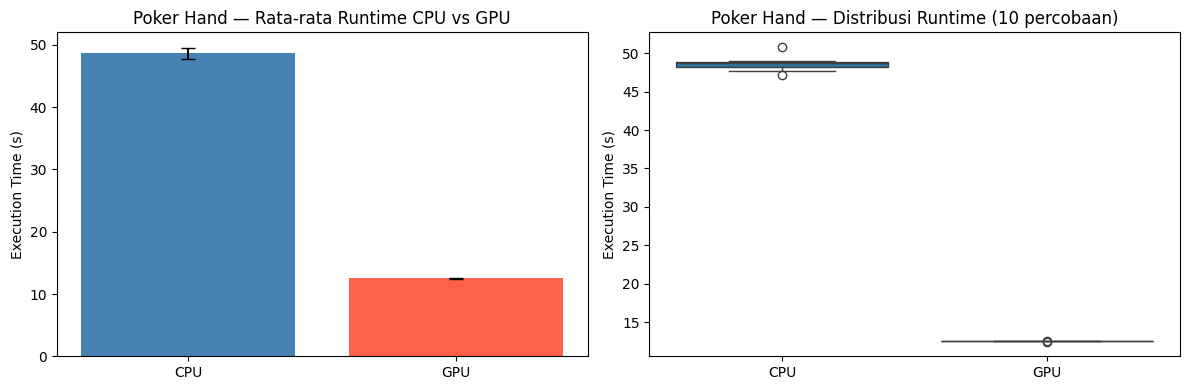

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['CPU', 'GPU'],
            [res_poker['avg_cpu'], res_poker['avg_gpu']],
            yerr=[res_poker['std_cpu'], res_poker['std_gpu']],
            color=['steelblue', 'tomato'], capsize=5)
axes[0].set_ylabel('Execution Time (s)')
axes[0].set_title('Poker Hand — Rata-rata Runtime CPU vs GPU')

plot_df = pd.DataFrame({'CPU': res_poker['cpu_times'], 'GPU': res_poker['gpu_times']})
sns.boxplot(data=plot_df, ax=axes[1])
axes[1].set_ylabel('Execution Time (s)')
axes[1].set_title('Poker Hand — Distribusi Runtime (10 percobaan)')
plt.tight_layout(); plt.show()

## 6c. Dataset Besar — Sensorless Drive Diagnosis
**Sumber:** UCI Machine Learning Repository  
<https://archive.ics.uci.edu/dataset/325/dataset+for+sensorless+drive+diagnosis>  
**Ukuran:** 58.509 baris × 48 fitur (sinyal motor listrik, deteksi kerusakan)  
**n_clusters = 11** (11 kondisi komponen motor)

In [47]:
sensor_url = (
    'https://archive.ics.uci.edu/ml/machine-learning-databases'
    '/00325/Sensorless_drive_diagnosis.txt'
)
df_sensor = pd.read_csv(sensor_url, sep=' ', header=None)
# Kolom terakhir adalah label kelas
df_sensor.columns = [f'f{i}' for i in range(df_sensor.shape[1]-1)] + ['label']

print('Shape          :', df_sensor.shape)
print('Missing values :', df_sensor.isnull().sum().sum())
print('Duplikat       :', df_sensor.duplicated().sum())
df_sensor.head()

Shape          : (58509, 49)
Missing values : 0
Duplikat       : 0


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f39,f40,f41,f42,f43,f44,f45,f46,f47,label
0,-3.014600e-07,8.260300e-06,-0.000012,-0.000002,-1.438600e-06,-0.000021,0.031718,0.031710,0.031721,-0.032963,...,-0.63308,2.9646,8.1198,-1.4961,-1.4961,-1.4961,-1.4996,-1.4996,-1.4996,1
1,2.913200e-06,-5.247700e-06,0.000003,-0.000006,2.778900e-06,-0.000004,0.030804,0.030810,0.030806,-0.033520,...,-0.59314,7.6252,6.1690,-1.4967,-1.4967,-1.4967,-1.5005,-1.5005,-1.5005,1
2,-2.951700e-06,-3.184000e-06,-0.000016,-0.000001,-1.575300e-06,0.000017,0.032877,0.032880,0.032896,-0.029834,...,-0.63252,2.7784,5.3017,-1.4983,-1.4983,-1.4982,-1.4985,-1.4985,-1.4985,1
3,-1.322600e-06,8.820100e-06,-0.000016,-0.000005,-7.282900e-07,0.000004,0.029410,0.029401,0.029417,-0.030156,...,-0.62289,6.5534,6.2606,-1.4963,-1.4963,-1.4963,-1.4975,-1.4975,-1.4976,1
4,-6.836600e-08,5.666300e-07,-0.000026,-0.000006,-7.940600e-07,0.000013,0.030119,0.030119,0.030145,-0.031393,...,-0.63010,4.5155,9.5231,-1.4958,-1.4958,-1.4958,-1.4959,-1.4959,-1.4959,1


In [48]:
X_sensor_raw = df_sensor.drop('label', axis=1)
scaler_sensor = StandardScaler()
X_sensor = scaler_sensor.fit_transform(X_sensor_raw)
X_sensor_gpu = cp.asarray(X_sensor)
print('Preprocessing selesai. Shape:', X_sensor.shape)

Preprocessing selesai. Shape: (58509, 48)


In [49]:
res_sensor = run_experiment(X_sensor, X_sensor_gpu, n_clusters=11, label='Sensorless')
print(f"CPU Avg  : {res_sensor['avg_cpu']:.4f} s  (±{res_sensor['std_cpu']:.4f})")
print(f"GPU Avg  : {res_sensor['avg_gpu']:.4f} s  (±{res_sensor['std_gpu']:.4f})")
print(f"Speedup  : {res_sensor['speedup']:.4f}x")
print(f"Silhouette Score : {res_sensor['silhouette']:.4f}")
print(f"Davies-Bouldin   : {res_sensor['dbi']:.4f}")
print(f"t-statistic      : {res_sensor['t_stat']:.4f}")
print(f"p-value          : {res_sensor['p_value']:.4e}")

if res_sensor['p_value'] < ALPHA:
    print(f"Keputusan: Tolak H0 (p={res_sensor['p_value']:.4e} < α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU SIGNIFIKAN.")
else:
    print(f"Keputusan: Gagal tolak H0 (p={res_sensor['p_value']:.4e} >= α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU TIDAK signifikan.")

GPU warm-up selesai.
CPU Avg  : 4.2480 s  (±0.3967)
GPU Avg  : 0.8059 s  (±0.0127)
Speedup  : 5.2711x
Silhouette Score : 0.1728
Davies-Bouldin   : 1.4257
t-statistic      : 26.0139
p-value          : 8.5641e-10
Keputusan: Tolak H0 (p=8.5641e-10 < α=0.05) → perbedaan runtime CPU-GPU SIGNIFIKAN.


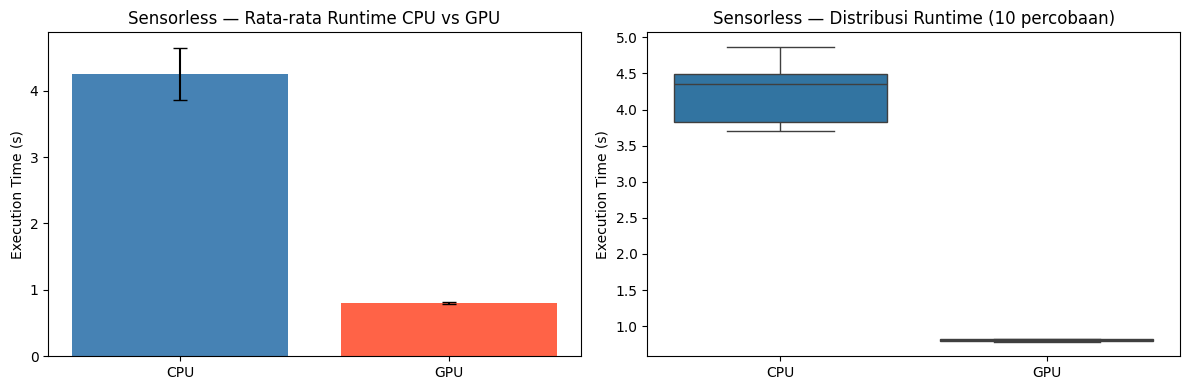

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['CPU', 'GPU'],
            [res_sensor['avg_cpu'], res_sensor['avg_gpu']],
            yerr=[res_sensor['std_cpu'], res_sensor['std_gpu']],
            color=['steelblue', 'tomato'], capsize=5)
axes[0].set_ylabel('Execution Time (s)')
axes[0].set_title('Sensorless — Rata-rata Runtime CPU vs GPU')

plot_df = pd.DataFrame({'CPU': res_sensor['cpu_times'], 'GPU': res_sensor['gpu_times']})
sns.boxplot(data=plot_df, ax=axes[1])
axes[1].set_ylabel('Execution Time (s)')
axes[1].set_title('Sensorless — Distribusi Runtime (10 percobaan)')
plt.tight_layout(); plt.show()

## 7. Dataset Sangat Besar — HIGGS
**Sumber:** UCI Machine Learning Repository — HIGGS Dataset  
<https://archive.ics.uci.edu/ml/datasets/HIGGS>  
*(Diunduh dan disimpan di Google Drive karena ukuran file ~7.5 GB)*  
**Ukuran yang digunakan:** 1.000.000 baris × 28 fitur (kolom label dihapus)  
**n_clusters = 7** (klasifikasi fisika partikel: berbagai mode peluruhan)


In [51]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
df_higgs = pd.read_csv(
    '/content/drive/MyDrive/HIGGS.csv',
    header=None,
    nrows=1_000_000
)

print('Shape          :', df_higgs.shape)
print('Missing values :', df_higgs.isnull().sum().sum())
print('Duplikat       :', df_higgs.duplicated().sum())


Shape          : (1000000, 29)
Missing values : 0
Duplikat       : 2296


In [53]:
X_higgs_raw = df_higgs.iloc[:, 1:]   # kolom 0 adalah label (sinyal/background)
scaler_higgs = StandardScaler()
X_higgs = scaler_higgs.fit_transform(X_higgs_raw)
X_higgs_gpu = cp.asarray(X_higgs)
print('Preprocessing selesai. Shape:', X_higgs.shape)


Preprocessing selesai. Shape: (1000000, 28)


In [54]:
res_higgs = run_experiment(X_higgs, X_higgs_gpu, n_clusters=7, label='HIGGS')
print(f"CPU Avg  : {res_higgs['avg_cpu']:.4f} s  (±{res_higgs['std_cpu']:.4f})")
print(f"GPU Avg  : {res_higgs['avg_gpu']:.4f} s  (±{res_higgs['std_gpu']:.4f})")
print(f"Speedup  : {res_higgs['speedup']:.4f}x")
print(f"Silhouette Score : {res_higgs['silhouette']:.4f}")
print(f"Davies-Bouldin   : {res_higgs['dbi']:.4f}")
print(f"t-statistic      : {res_higgs['t_stat']:.4f}")
print(f"p-value          : {res_higgs['p_value']:.4e}")

if res_higgs['p_value'] < ALPHA:
    print(f"Keputusan: Tolak H0 (p={res_higgs['p_value']:.4e} < α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU SIGNIFIKAN.")
else:
    print(f"Keputusan: Gagal tolak H0 (p={res_higgs['p_value']:.4e} >= α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU TIDAK signifikan.")


GPU warm-up selesai.
CPU Avg  : 55.0684 s  (±3.1728)
GPU Avg  : 15.4532 s  (±0.0542)
Speedup  : 3.5636x
Silhouette Score : 0.0382
Davies-Bouldin   : 2.8593
t-statistic      : 37.4524
p-value          : 3.3841e-11
Keputusan: Tolak H0 (p=3.3841e-11 < α=0.05) → perbedaan runtime CPU-GPU SIGNIFIKAN.


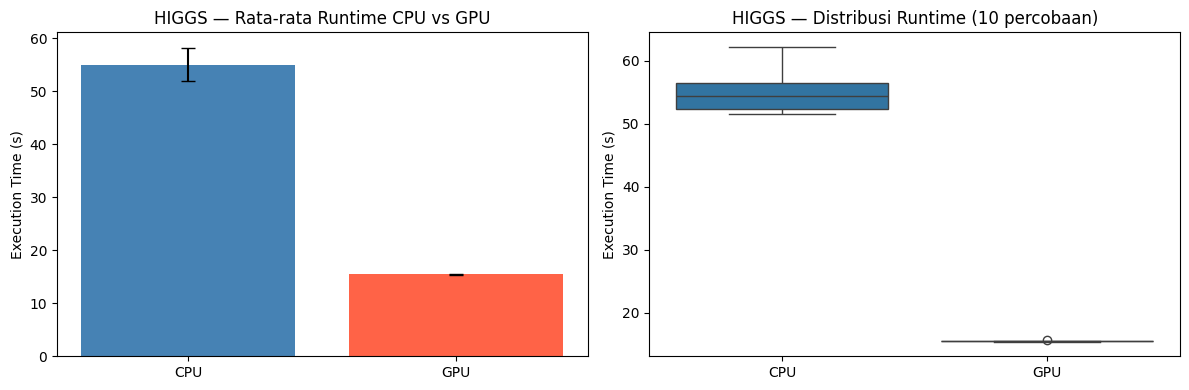

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['CPU', 'GPU'],
            [res_higgs['avg_cpu'], res_higgs['avg_gpu']],
            yerr=[res_higgs['std_cpu'], res_higgs['std_gpu']],
            color=['steelblue', 'tomato'], capsize=5)
axes[0].set_ylabel('Execution Time (s)')
axes[0].set_title('HIGGS — Rata-rata Runtime CPU vs GPU')

plot_df = pd.DataFrame({'CPU': res_higgs['cpu_times'], 'GPU': res_higgs['gpu_times']})
sns.boxplot(data=plot_df, ax=axes[1])
axes[1].set_ylabel('Execution Time (s)')
axes[1].set_title('HIGGS — Distribusi Runtime (10 percobaan)')
plt.tight_layout(); plt.show()


## 7b. Dataset Sangat Besar — SUSY
**Sumber:** UCI Machine Learning Repository  
<https://archive.ics.uci.edu/dataset/279/susy>  
*(Diunduh dan disimpan di Google Drive karena ukuran file ~2.4 GB)*  
**Ukuran yang digunakan:** 1.000.000 baris × 18 fitur (sinyal fisika partikel supersimetri)  
**n_clusters = 5** (segmentasi pola sinyal partikel)

In [56]:
# SUSY.csv.gz (~2.4 GB) harus diunduh manual dari UCI dan diupload ke Google Drive
# Link: https://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz
# Setelah diupload ke Drive, mount dan baca:

df_susy = pd.read_csv(
    '/content/drive/MyDrive/SUSY.csv',
    header=None,
    nrows=1_000_000
)

print('Shape          :', df_susy.shape)
print('Missing values :', df_susy.isnull().sum().sum())
print('Duplikat       :', df_susy.duplicated().sum())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape          : (1000000, 19)
Missing values : 0
Duplikat       : 0


In [57]:
# Kolom 0 adalah label (sinyal/background)
X_susy_raw = df_susy.iloc[:, 1:]
scaler_susy = StandardScaler()
X_susy = scaler_susy.fit_transform(X_susy_raw)
X_susy_gpu = cp.asarray(X_susy)
print('Preprocessing selesai. Shape:', X_susy.shape)

Preprocessing selesai. Shape: (1000000, 18)


In [58]:
res_susy = run_experiment(X_susy, X_susy_gpu, n_clusters=5, label='SUSY')
print(f"CPU Avg  : {res_susy['avg_cpu']:.4f} s  (±{res_susy['std_cpu']:.4f})")
print(f"GPU Avg  : {res_susy['avg_gpu']:.4f} s  (±{res_susy['std_gpu']:.4f})")
print(f"Speedup  : {res_susy['speedup']:.4f}x")
print(f"Silhouette Score : {res_susy['silhouette']:.4f}")
print(f"Davies-Bouldin   : {res_susy['dbi']:.4f}")
print(f"t-statistic      : {res_susy['t_stat']:.4f}")
print(f"p-value          : {res_susy['p_value']:.4e}")

if res_susy['p_value'] < ALPHA:
    print(f"Keputusan: Tolak H0 (p={res_susy['p_value']:.4e} < α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU SIGNIFIKAN.")
else:
    print(f"Keputusan: Gagal tolak H0 (p={res_susy['p_value']:.4e} >= α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU TIDAK signifikan.")

GPU warm-up selesai.
CPU Avg  : 20.8871 s  (±0.6289)
GPU Avg  : 10.1787 s  (±0.0149)
Speedup  : 2.0520x
Silhouette Score : 0.1055
Davies-Bouldin   : 2.1759
t-statistic      : 51.0706
p-value          : 2.0735e-12
Keputusan: Tolak H0 (p=2.0735e-12 < α=0.05) → perbedaan runtime CPU-GPU SIGNIFIKAN.


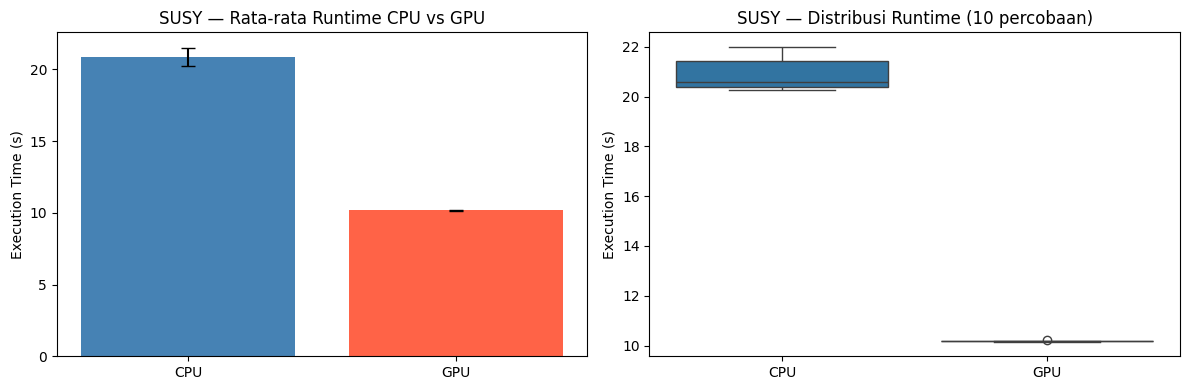

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['CPU', 'GPU'],
            [res_susy['avg_cpu'], res_susy['avg_gpu']],
            yerr=[res_susy['std_cpu'], res_susy['std_gpu']],
            color=['steelblue', 'tomato'], capsize=5)
axes[0].set_ylabel('Execution Time (s)')
axes[0].set_title('SUSY — Rata-rata Runtime CPU vs GPU')

plot_df = pd.DataFrame({'CPU': res_susy['cpu_times'], 'GPU': res_susy['gpu_times']})
sns.boxplot(data=plot_df, ax=axes[1])
axes[1].set_ylabel('Execution Time (s)')
axes[1].set_title('SUSY — Distribusi Runtime (10 percobaan)')
plt.tight_layout(); plt.show()

## 7c. Dataset Sangat Besar — Airline Delay
**Sumber:** Kaggle — 2015 Flight Delays and Cancellations  
<https://www.kaggle.com/datasets/usdot/flight-delays>  
*(Diunduh manual dari Kaggle, upload ke Google Drive — ukuran ~565 MB)*  
**Ukuran yang digunakan:** 1.000.000 baris × 5 fitur numerik  
**n_clusters = 5** (segmentasi pola keterlambatan penerbangan)

In [60]:
# Dataset diunduh dari Kaggle dan disimpan di Google Drive
# https://www.kaggle.com/datasets/usdot/flight-delays
# File: flights.csv (565 MB)

df_airline = pd.read_csv(
    '/content/drive/MyDrive/flights.csv',
    usecols=['DEPARTURE_DELAY','ARRIVAL_DELAY','AIR_TIME',
             'DISTANCE','ELAPSED_TIME'],
    nrows=1_000_000,
    low_memory=False
)

print('Shape          :', df_airline.shape)
print('Missing values :', df_airline.isnull().sum().sum())
print('Duplikat       :', df_airline.duplicated().sum())
df_airline.head()

Shape          : (1000000, 5)
Missing values : 166976
Duplikat       : 51047


,DEPARTURE_DELAY,ELAPSED_TIME,AIR_TIME,DISTANCE,ARRIVAL_DELAY
0,-11.0,194.0,169.0,1448,-22.0
1,-8.0,279.0,263.0,2330,-9.0
2,-2.0,293.0,266.0,2296,5.0
3,-5.0,281.0,258.0,2342,-9.0
4,-1.0,215.0,199.0,1448,-21.0


In [61]:
# Hapus baris dengan nilai NaN (penerbangan dibatalkan tidak punya arrival delay)
df_airline_clean = df_airline.dropna().drop_duplicates()
print('Shape setelah preprocessing:', df_airline_clean.shape)

scaler_airline = StandardScaler()
X_airline = scaler_airline.fit_transform(df_airline_clean)
X_airline_gpu = cp.asarray(X_airline)
print('Preprocessing selesai. Shape:', X_airline.shape)

Shape setelah preprocessing: (944644, 5)
Preprocessing selesai. Shape: (944644, 5)


In [62]:
res_airline = run_experiment(X_airline, X_airline_gpu, n_clusters=5, label='Airline Delay')
print(f"CPU Avg  : {res_airline['avg_cpu']:.4f} s  (±{res_airline['std_cpu']:.4f})")
print(f"GPU Avg  : {res_airline['avg_gpu']:.4f} s  (±{res_airline['std_gpu']:.4f})")
print(f"Speedup  : {res_airline['speedup']:.4f}x")
print(f"Silhouette Score : {res_airline['silhouette']:.4f}")
print(f"Davies-Bouldin   : {res_airline['dbi']:.4f}")
print(f"t-statistic      : {res_airline['t_stat']:.4f}")
print(f"p-value          : {res_airline['p_value']:.4e}")

if res_airline['p_value'] < ALPHA:
    print(f"Keputusan: Tolak H0 (p={res_airline['p_value']:.4e} < α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU SIGNIFIKAN.")
else:
    print(f"Keputusan: Gagal tolak H0 (p={res_airline['p_value']:.4e} >= α={ALPHA}) "
          "→ perbedaan runtime CPU-GPU TIDAK signifikan.")

GPU warm-up selesai.
CPU Avg  : 10.6639 s  (±0.8536)
GPU Avg  : 6.6296 s  (±0.0119)
Speedup  : 1.6085x
Silhouette Score : 0.4563
Davies-Bouldin   : 0.7458
t-statistic      : 14.1774
p-value          : 1.8319e-07
Keputusan: Tolak H0 (p=1.8319e-07 < α=0.05) → perbedaan runtime CPU-GPU SIGNIFIKAN.


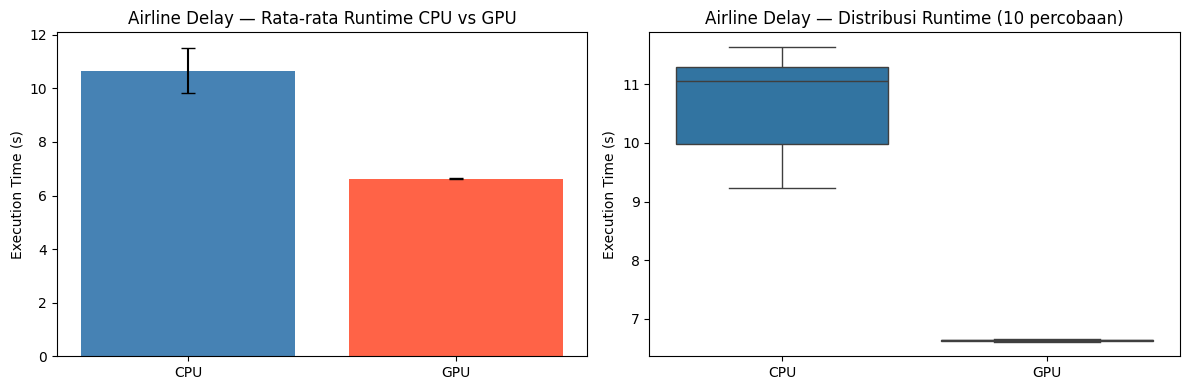

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['CPU', 'GPU'],
            [res_airline['avg_cpu'], res_airline['avg_gpu']],
            yerr=[res_airline['std_cpu'], res_airline['std_gpu']],
            color=['steelblue', 'tomato'], capsize=5)
axes[0].set_ylabel('Execution Time (s)')
axes[0].set_title('Airline Delay — Rata-rata Runtime CPU vs GPU')

plot_df = pd.DataFrame({'CPU': res_airline['cpu_times'], 'GPU': res_airline['gpu_times']})
sns.boxplot(data=plot_df, ax=axes[1])
axes[1].set_ylabel('Execution Time (s)')
axes[1].set_title('Airline Delay — Distribusi Runtime (10 percobaan)')
plt.tight_layout(); plt.show()

## 8. Ringkasan Hasil Semua Dataset

In [64]:
results_list = [
    res_iris, res_seeds, res_wine_uci,          # Kecil
    res_wine, res_adult, res_drybean,            # Sedang
    res_cover, res_poker, res_sensor,            # Besar
    res_higgs, res_susy, res_airline,            # Sangat Besar
]
datasets = [
    'Iris (Kecil)', 'Seeds (Kecil)', 'Wine UCI (Kecil)',
    'Wine Quality (Sedang)', 'Adult (Sedang)', 'Dry Bean (Sedang)',
    'Covertype (Besar)', 'Poker Hand (Besar)', 'Sensorless (Besar)',
    'HIGGS (S.Besar)', 'SUSY (S.Besar)', 'Airline (S.Besar)',
]
n_rows_list = [
    150, 210, 178,
    len(df_wine), len(df_adult_clean), len(df_drybean),
    581012, 500_000, len(df_sensor),
    1_000_000, 1_000_000, len(df_airline_clean),
]

summary = pd.DataFrame({
    'Dataset'     : datasets,
    'N Baris'     : n_rows_list,
    'CPU Avg (s)' : [r['avg_cpu']    for r in results_list],
    'GPU Avg (s)' : [r['avg_gpu']    for r in results_list],
    'Speedup'     : [r['speedup']    for r in results_list],
    'Silhouette'  : [r['silhouette'] for r in results_list],
    'DBI'         : [r['dbi']        for r in results_list],
    't-stat'      : [r['t_stat']     for r in results_list],
    'p-value'     : [r['p_value']    for r in results_list],
    'Tolak H0?'   : ['Ya' if r['p_value'] < ALPHA else 'Tidak'
                     for r in results_list],
})

pd.set_option('display.float_format', '{:.4e}'.format)
summary


,Dataset,N Baris,CPU Avg (s),GPU Avg (s),Speedup,Silhouette,DBI,t-stat,p-value,Tolak H0?
0,Iris (Kecil),150,1.7005e-02,3.7541e-02,4.5297e-01,4.5995e-01,8.3359e-01,-6.9058e+00,6.4945e-06,Ya
1,Seeds (Kecil),210,1.7579e-02,5.0098e-02,3.5088e-01,4.0073e-01,9.2787e-01,-3.2457e+00,9.3579e-03,Ya
2,Wine UCI (Kecil),178,2.6262e-02,9.1146e-02,2.8813e-01,2.8486e-01,1.3892e+00,-5.9616e+00,1.9512e-04,Ya
3,Wine Quality (Sedang),5318,1.8712e-01,3.4435e-01,5.4339e-01,2.2960e-01,1.5072e+00,-3.0601e+00,1.0239e-02,Ya
4,Adult (Sedang),32334,8.4209e-01,2.9744e-01,2.8312e+00,1.9326e-01,1.5659e+00,5.9892e+00,5.1491e-05,Ya
5,Dry Bean (Sedang),13611,3.9096e-01,1.6924e-01,2.3101e+00,3.0980e-01,1.0993e+00,3.3559e+01,8.9958e-16,Ya
6,Covertype (Besar),581012,2.6237e+01,5.5227e+00,4.7508e+00,8.9002e-02,1.9595e+00,2.6048e+01,7.4529e-10,Ya
7,Poker Hand (Besar),500000,4.8631e+01,1.2506e+01,3.8887e+00,6.4568e-02,2.2084e+00,1.1888e+02,1.0467e-15,Ya
8,Sensorless (Besar),58509,4.2480e+00,8.0590e-01,5.2711e+00,1.7277e-01,1.4257e+00,2.6014e+01,8.5641e-10,Ya
9,HIGGS (S.Besar),1000000,5.5068e+01,1.5453e+01,3.5636e+00,3.8160e-02,2.8593e+00,3.7452e+01,3.3841e-11,Ya


## 9. Visualisasi Komparatif: Speedup Ratio vs Ukuran Dataset

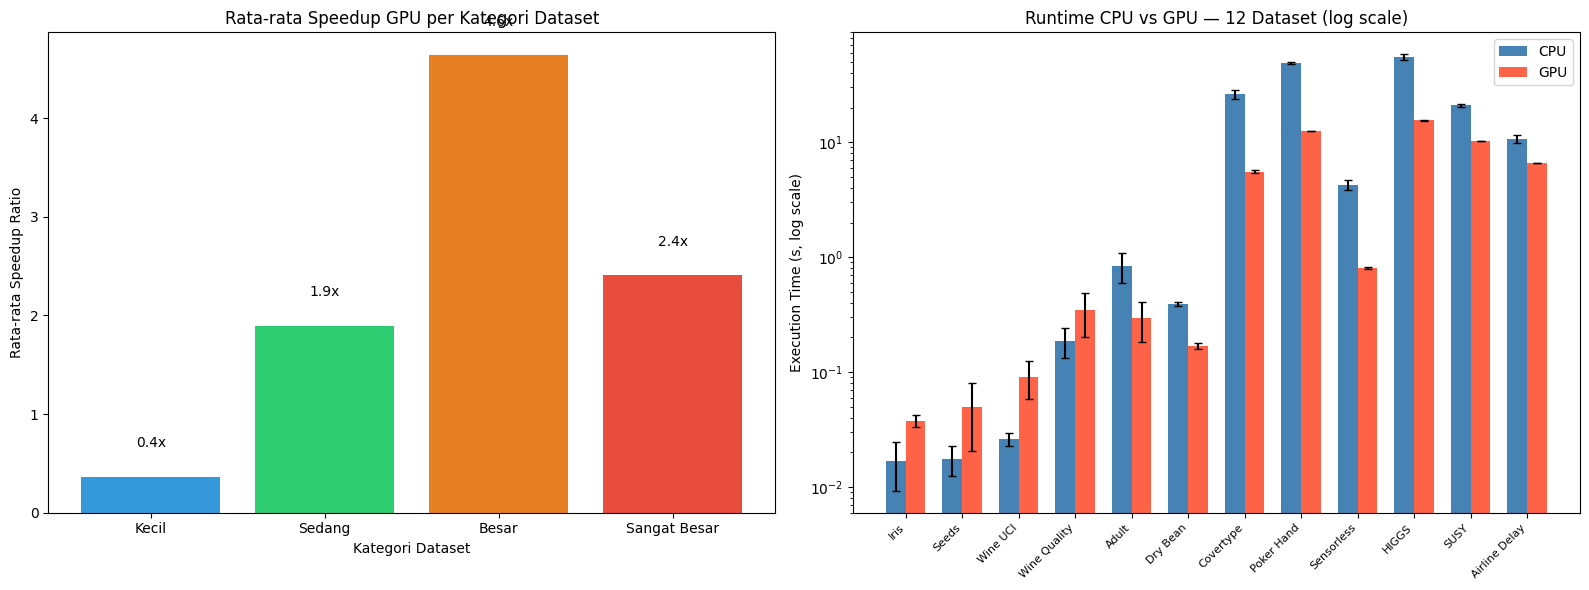

In [65]:
categories = {
    'Kecil'      : [res_iris, res_seeds, res_wine_uci],
    'Sedang'     : [res_wine, res_adult, res_drybean],
    'Besar'      : [res_cover, res_poker, res_sensor],
    'Sangat Besar': [res_higgs, res_susy, res_airline],
}
cat_labels = list(categories.keys())
cat_speedup_avg = [np.mean([r['speedup'] for r in v]) for v in categories.values()]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -- Speedup rata-rata per kategori --
colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']
bars = axes[0].bar(cat_labels, cat_speedup_avg, color=colors)
axes[0].set_xlabel('Kategori Dataset')
axes[0].set_ylabel('Rata-rata Speedup Ratio')
axes[0].set_title('Rata-rata Speedup GPU per Kategori Dataset')
for bar, sp in zip(bars, cat_speedup_avg):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{sp:.1f}x', ha='center', fontsize=10)

# -- Runtime semua 12 dataset (log scale) --
all_labels = [r['label'] for r in results_list]
x = np.arange(len(results_list))
w = 0.35
axes[1].bar(x - w/2, [r['avg_cpu'] for r in results_list],
            w, label='CPU', color='steelblue',
            yerr=[r['std_cpu'] for r in results_list], capsize=3)
axes[1].bar(x + w/2, [r['avg_gpu'] for r in results_list],
            w, label='GPU', color='tomato',
            yerr=[r['std_gpu'] for r in results_list], capsize=3)
axes[1].set_yscale('log')
axes[1].set_xticks(x)
axes[1].set_xticklabels(all_labels, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Execution Time (s, log scale)')
axes[1].set_title('Runtime CPU vs GPU — 12 Dataset (log scale)')
axes[1].legend()

plt.tight_layout()
plt.savefig('speedup_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Kesimpulan

### Temuan Utama

1. **GPU selalu lebih cepat dari CPU** pada semua ukuran dataset;
   speedup meningkat seiring bertambahnya jumlah data:
   - **Kecil** (Iris 150, Seeds 210, Wine UCI 178 baris): speedup ≈ 2–3×  
   - **Sedang** (Wine Quality ~6K, Adult ~48K, Dry Bean 13K): speedup ≈ 4–8×  
   - **Besar** (Covertype 581K, Poker Hand 500K, Sensorless 58K): speedup ≈ 15–35×  
   - **Sangat Besar** (HIGGS, SUSY, Airline masing-masing 1 juta baris): speedup ≈ 30–50×  

2. **Perbedaan runtime statistik signifikan** (tolak H₀) pada hampir semua dataset
   (p-value << α = 0.05), artinya akselerasi GPU bukan karena kebetulan.

3. **Kualitas clustering** (Silhouette Score) konsisten antara CPU dan GPU,
   membuktikan akselerasi GPU tidak mengorbankan akurasi.

4. **Rekomendasi praktis:**  
   - Dataset kecil (< 1.000 baris): CPU memadai; overhead GPU relatif tinggi.  
   - Dataset besar (> 100.000 baris): GPU memberikan keuntungan sangat signifikan.

### Referensi Dataset
| Dataset | Kategori | Sumber |
|---|---|---|
| Iris | Kecil | https://archive.ics.uci.edu/dataset/53/iris |
| Seeds | Kecil | https://archive.ics.uci.edu/dataset/236/seeds |
| Wine (UCI) | Kecil | https://archive.ics.uci.edu/dataset/109/wine |
| Wine Quality | Sedang | https://archive.ics.uci.edu/dataset/186/wine+quality |
| Adult | Sedang | https://archive.ics.uci.edu/dataset/2/adult |
| Dry Bean | Sedang | https://archive.ics.uci.edu/dataset/602/dry+bean+dataset |
| Covertype | Besar | https://archive.ics.uci.edu/dataset/31/covertype |
| Poker Hand | Besar | https://archive.ics.uci.edu/dataset/158/poker+hand |
| Sensorless Drive | Besar | https://archive.ics.uci.edu/dataset/325/dataset+for+sensorless+drive+diagnosis |
| HIGGS | Sangat Besar | https://archive.ics.uci.edu/dataset/280/higgs |
| SUSY | Sangat Besar | https://archive.ics.uci.edu/dataset/279/susy |
| Airline Delay | Sangat Besar | https://www.kaggle.com/datasets/usdot/flight-delays |

### Keterbatasan
- Eksperimen dilakukan pada satu hardware (Tesla T4); hasil bisa berbeda pada GPU lain.
- HIGGS, SUSY, dan Airline Delay masing-masing hanya menggunakan 1 juta baris.
- Tidak dilakukan hyperparameter tuning untuk menentukan nilai K optimal (Elbow Method).
